|                |   |
:----------------|---|
| **Nombres**     | Jocelyn Jiménez
| **Fecha**      | 03/05/26  |

# **T09 - Resampling**

`Conceptuales`

**1.** Using basic statistical properties of the variance, as well as singlevariable calculus, derive (5.6). In other words, prove that α given by
(5.6) does indeed minimize Var(αX + (1 − α)Y ).

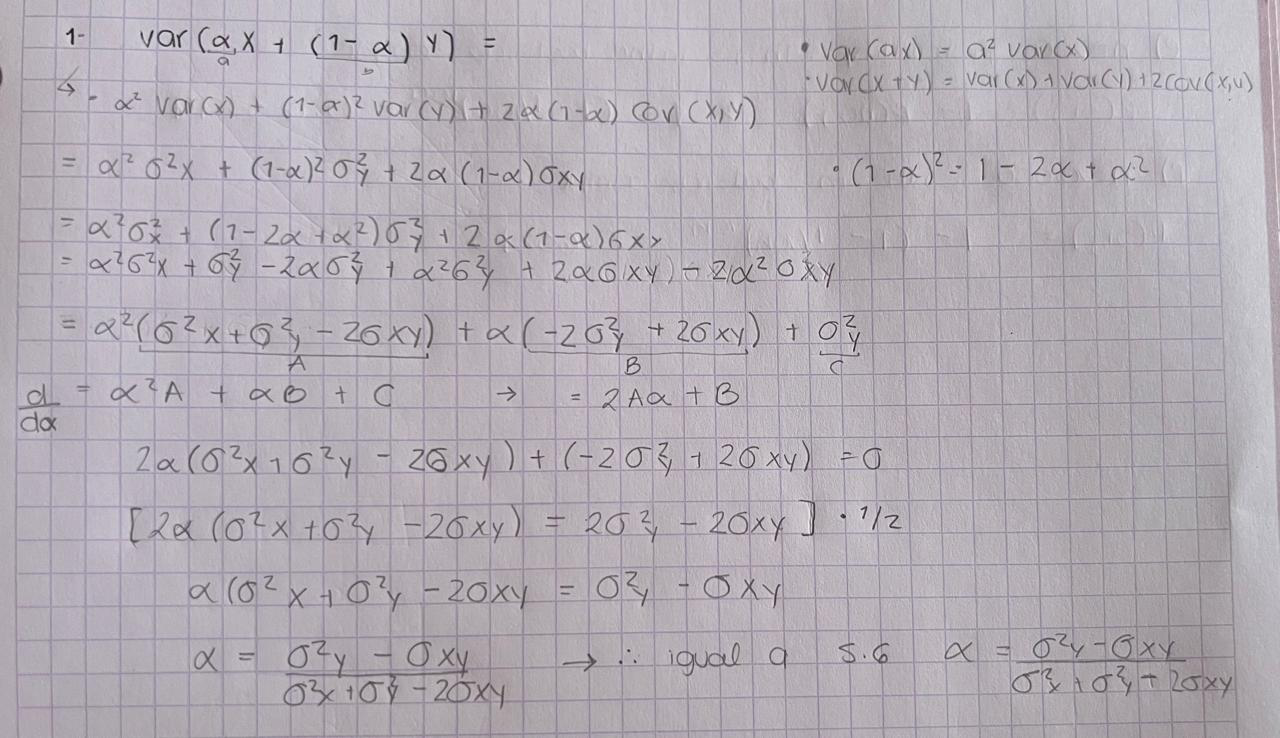

**2.** We will now derive the probability that a given observation is part
of a bootstrap sample. Suppose that we obtain a bootstrap sample
from a set of n observations.

> **(a)** What is the probability that the first bootstrap observation is not the jth observation from the original sample? Justify your answer.

P(j) = 1/n

P(no j) = 1 - P(j)  -> **P(no j) = 1 - (1/n)**

Se usa complemento porque nos dice que no se tiene que elegir el jth por lo tanto, 1-p(j)

> **(b)** What is the probability that the second bootstrap observation
is not the jth observation from the original sample?

P(no j) = 1 - (1/n)

No importa que sea el segundo intento, como es de reemplazo se sigue teniendo la misma cantidad de n y la misma probabilidad. Cada observación es independiente.

> **(c)** Argue that the probability that the jth observation is not in the
bootstrap sample is (1 − 1/n)n

Como cada observación es independiente y la P(no j) = 1 - 1/n, cada intento sucede lo siguiente:

(1-1/n) * (1-1/n) * (1-1/n) * ... (n veces)

Por lo tanto, nos da **P(no j) = (1-1/n)^n**

> **(d)** When n = 5, what is the probability that the jth observation is
in the bootstrap sample?

P(si j) = 1 - P(no j) -> **P(si j) = 1 - (1 - 1/n)^n**

P(si j) = 1 - (1 - 1/5)^5 = ***0.67232***

In [47]:
n = 5
Pd = 1 - (1-1/n)**n

print(f"La Probabilidad de de que j si esté en el bootstrap es: {Pd}")

La Probabilidad de de que j si esté en el bootstrap es: 0.6723199999999999




> **(e)** When n = 100, what is the probability that the jth observation
is in the bootstrap sample?



P(si j) = 1 - P(no j) -> P(si j) = 1 - (1 - 1/n)^n

P(si j) = 1 - (1 - 1/100)^100 = ***0.63396***

In [48]:
n = 100
Pe = 1 - (1-1/n)**n

print(f"La Probabilidad de de que j si esté en el bootstrap es: {Pe}")

La Probabilidad de de que j si esté en el bootstrap es: 0.6339676587267709




> **(f)** When n = 10, 000, what is the probability that the jth observation is in the bootstrap sample?



P(si j) = 1 - P(no j) -> P(si j) = 1 - (1 - 1/n)^n

P(si j) = 1 - (1 - 1/10000)^10000 = ***0.63213***

In [49]:
n = 10000
Pf = 1 - (1-1/n)**n

print(f"La Probabilidad de de que j si esté en el bootstrap es: {Pf}")

La Probabilidad de de que j si esté en el bootstrap es: 0.6321389535670295




> **(g)** Create a plot that displays, for each integer value of n from 1
to 100, 000, the probability that the jth observation is in the
bootstrap sample. Comment on what you observe.



In [50]:
import numpy as np
import matplotlib.pyplot as plt

In [51]:
n = np.arange(1, 100001)

In [52]:
Pg = 1 - (1 - 1/n)**n

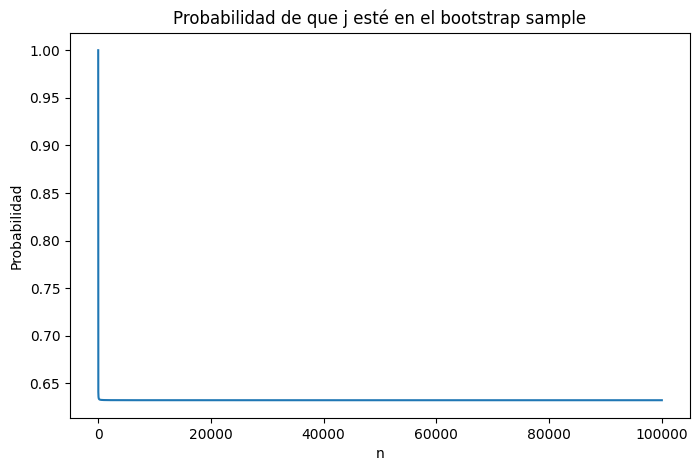

In [53]:
plt.figure(figsize=(8,5))
plt.plot(n, Pg)
plt.xlabel('n')
plt.ylabel('Probabilidad')
plt.title('Probabilidad de que j esté en el bootstrap sample')
plt.show()

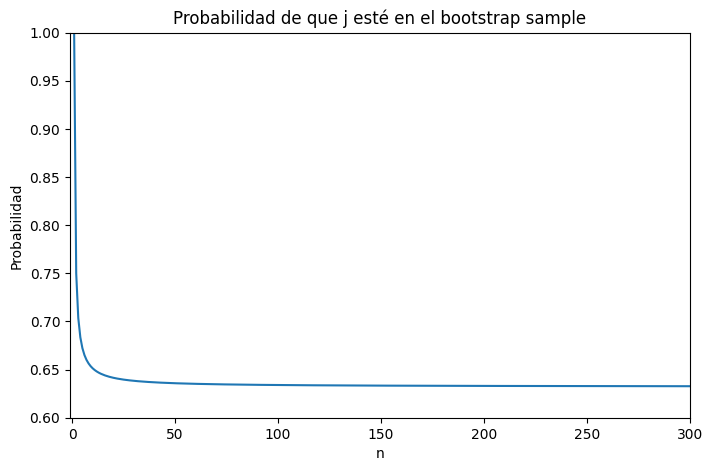

In [54]:
plt.figure(figsize=(8,5))
plt.xlim(-1, 300)
plt.ylim(0.6, 1)
plt.plot(n, Pg)
plt.xlabel('n')
plt.ylabel('Probabilidad')
plt.title('Probabilidad de que j esté en el bootstrap sample')
plt.show()

Como se puede observa cada vez que aumenta la n, la probabilidad se acerca a a un límite, es decir la probabilidad deja de aumentsar. Lo cual nos dice que, aunque el tamaño de muestra sea muy grande la probabilidad tiende a un valor constante.



> **(h)** We will now investigate numerically the probability that a bootstrap sample of size n = 100 contains the jth observation. Here j = 4. We first create an array store with values that will subsequently be overwritten using the function np.empty(). We then repeatedly create bootstrap samples, and each time we record whether or not the fifth observation is contained in the bootstrap sample.



In [55]:
rng = np.random.default_rng(10) #aleatorio
store = np.empty(10000) #en donde se guardan los resultados

for i in range(10000): #se hacen 10000 bootstraps
    store[i] = np.sum(rng.choice(100, size=100, replace=True) == 4) > 0 #se crea un bootstrap sample de tamaño 100 con reemplazo. en donde si aparece 4 = True

np.mean(store) #promedio de las veces que aparece 4

np.float64(0.6362)

Como se puede observar se generaron 10,000 muestras bootstrap de tamaño 100 con reemplazo. En cada una se analizaba si aparecía j=4 y si era así = True, después se guardaba en "store" para al final obtener el promedio de las veces que salio 4. el promedio nos dio 0.6362, el cual coincide con la conclusión de la gráfica en donde se menciona que entre mas muestras tengas la probabilidad llega a tener un valor constante aproximadamente de .63

**3.** We now review k-fold cross-validation.



> **(a)** Explain how k-fold cross-validation is implemented.



Los k-folds van a dividir el dataset en k partes iguales. El modelo se entrana K veces -1 para usar ese fold restante para validar. Por último se promedian los errores de cada iteración para obtener el error final.



> **(b)** What are the advantages and disadvantages of k-fold crossvalidation relative to:



-      i. The validation set approach?

El k-fold comparado con validation set approach, nos da una predicción más precisa del error, ya que se usan mas datos para el entrenamiento del modelo, pero una desventaja que presenta es que mas pesado al momento de entrenarlo múltiples veces.

Validation set approach es más rápido

-      ii. LOOCV?

k-fold cross-validation a comparación del LOOCV es menos pesado en cuestión de entrenar al modelo k veces. Por el otro lado, puede llegar a presentar un cierto sesgo.

**4.** Suppose that we use some statistical learning method to make a prediction for the response Y for a particular value of the predictor X.
Carefully describe how we might estimate the standard deviation of
our prediction.

De nuestro dataset se hacen varias muestras de bootstrap u en cada una se entrana el modelo para después obtener la predicción de cada una. Una vez hecho esto, se calcula la desviación estándar de esas predicciones en conjunto

`Prácticos`

**5.** In Chapter 4, we used logistic regression to predict the probability of
default using income and balance on the Default data set. We will now estimate the test error of this logistic regression model using the validation set approach. Do not forget to set a random seed before beginning your analysis.

In [56]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Default.csv")
df.head()

Saving Default.csv to Default (1).csv


,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


In [57]:
df['default'] = df['default'].map({'No':0, 'Yes':1})
df['student'] = df['student'].map({'No':0, 'Yes':1})


> **(a)** Fit a logistic regression model that uses income and balance to predict default.


In [58]:
X = df[['income', 'balance']]
y = df['default']

In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

LogisticRegression()




> **(b)** Using the validation set approach, estimate the test error of this
model. In order to do this, you must perform the following steps:

1. Split the sample set into a training set and a validation set.
2. Fit a multiple logistic regression model using only the training observations.
3.  Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.
4.  Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.



In [60]:
np.random.seed(1)

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=1)

In [62]:
model.fit(X_train, y_train)

LogisticRegression()

In [63]:
probs = model.predict_proba(X_val)[:, 1]

y_pred = (probs > 0.5).astype(int)

In [64]:
error = np.mean(y_pred != y_val)
error

np.float64(0.024666666666666667)

El error de validación es de 0.0246, lo que nos dice que el modelo clasifica incorrectamente alrededor del 2.47% de las observaciones. Por lo tanto, el modelo tiene un buen desempeño en cuestión de predicción.



> **(c)** Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained.



In [65]:
errores = []

for i in [1, 2, 3]:
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=i)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_val)[:, 1]
    y_pred = (probs > 0.5).astype(int)

    error = np.mean(y_pred != y_val)
    errores.append(error)

errores

[np.float64(0.024666666666666667),
 np.float64(0.023666666666666666),
 np.float64(0.025)]

Como se puede observar dependiendo de como se parten los datos la estimación del error tiene una pequeña diferencia.



> **(d)** Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a dummy variable for student leads to a reduction in the test error rate.



In [66]:
X2 = df[['income', 'balance', 'student']]

In [67]:
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y, test_size=0.3, random_state=1)

In [68]:
model2 = LogisticRegression()
model2.fit(X2_train, y2_train)

LogisticRegression()

In [69]:
probs2 = model2.predict_proba(X2_val)[:, 1]
y_pred2 = (probs2 > 0.5).astype(int)

In [70]:
error2 = np.mean(y_pred2 != y2_val)
error2

np.float64(0.024333333333333332)

Conclusión:

Al incluir la variable student en el modelo, se observó una pequeña diferencia de .0246 (inciso b) -> 0.243 (inciso d). Lo cual nos dice que la variable student no aporta mucha información para la predicción de default.

**6.** We continue to consider the use of a logistic regression model to
predict the probability of default using income and balance on the Default data set. In particular, we will now compute estimates for the standard errors of the income and balance logistic regression coefficients in two different ways: (1) using the bootstrap, and (2) using the standard formula for computing the standard errors in the sm.GLM() function. Do not forget to set a random seed before beginning your
analysis.



>**(a)** Using the summarize() and sm.GLM() functions, determine the estimated standard errors for the coefficients associated with income and balance in a multiple logistic regression model that uses both predictors



In [71]:
import statsmodels.api as sm

In [72]:
X = df[['income', 'balance']]
y = df['default']

In [73]:
X = sm.add_constant(X)

In [74]:
model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Mon, 04 May 2026   Deviance:                       1579.0
Time:                        01:08:54   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.5405      0.435    -26.544      0.0



> **(b)** Write a function, boot_fn(), that takes as input the Default data set as well as an index of the observations, and that outputs the coefficient estimates for income and balance in the multiple logistic regression model.



In [75]:
def boot_fn(data, index):

    sample = data.iloc[index]

    X = sample[['income', 'balance']]
    y = sample['default']

    X = sm.add_constant(X)

    model2 = sm.GLM(y, X, family=sm.families.Binomial())
    results = model2.fit()

    return results.params[['income', 'balance']]

In [76]:
boot_fn(df, np.random.choice(len(df), len(df), replace=True))

,0
income,0.000019
balance,0.005751




> **(c)** Following the bootstrap example in the lab, use your boot_fn() function to estimate the standard errors of the logistic regression coefficients for income and balance.



In [77]:
np.random.seed(1)

In [78]:
boot_coefs = []

n = len(df)

for i in range(1000):

    index = np.random.choice(n, n, replace=True)

    coefs = boot_fn(df, index)

    boot_coefs.append(coefs)

boot_coefs = np.array(boot_coefs)

boot_se = boot_coefs.std(axis=0)

boot_se

array([5.02857778e-06, 2.32794756e-04])



> **(d)** Comment on the estimated standard errors obtained using the sm.GLM() function and using the bootstrap.



Como se pued eobservar los errores estándar estimados mediante bootstrap son  similares a los obtenidos con la función GLM. Lo cual nos dice que ambas formas nos ayudan a estimar errores consistentes, son confiables.


**7.** In Sections 5.1.2 and 5.1.3, we saw that the cross_validate() function can be used in order to compute the LOOCV test error estimate. Alternatively, one could compute those quantities using just sm.GLM() and the predict() method of the fitted model within a for loop. You will now take this approach in order to compute the LOOCV error for a simple logistic regression model on the Weekly data set. Recall that in the context of classification problems, the LOOCV error is given in (5.4).

In [80]:
!pip install ISLP
from ISLP import load_data

df2= load_data("Weekly")
df2.head()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=8d44a181e7abdad1a9922d1fff53595c9424d5c30213b09df0dca7581ae4563c
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [81]:
df2['Direction'] = df2['Direction'].map({'Down':0, 'Up':1})

In [82]:
df2.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,0
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,0
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,1
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,1
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,1




> (a) Fit a logistic regression model that predicts Direction using Lag1
and Lag2.



In [83]:
x2 = df2[['Lag1', 'Lag2']]
y2 = df2['Direction']

X2 = sm.add_constant(x2)

In [84]:
model_week = sm.GLM(y2, X2, family=sm.families.Binomial())
results = model_week.fit()

print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1086
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -744.11
Date:                Mon, 04 May 2026   Deviance:                       1488.2
Time:                        01:39:00   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007303
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2212      0.061      3.599      0.0



> (b) Fit a logistic regression model that predicts Direction using Lag1
and Lag2 using all but the first observation.


In [85]:
df2_b = df2.iloc[1:]

In [86]:
X_b = df2_b[['Lag1', 'Lag2']]
y_b = df2_b['Direction']

X_b = sm.add_constant(X_b)

In [87]:
model_b = sm.GLM(y_b, X_b, family=sm.families.Binomial())
results_b = model_b.fit()

print(results_b.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1088
Model:                            GLM   Df Residuals:                     1085
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.26
Date:                Mon, 04 May 2026   Deviance:                       1486.5
Time:                        01:40:52   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007373
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2232      0.061      3.630      0.0



> (c) Use the model from (b) to predict the direction of the first observation. You can do this by predicting that the first observation will go up if P(Direction = "Up"|Lag1, Lag2) > 0.5. Was this observation correctly classified?



In [89]:
X_first = df2.iloc[[0]][['Lag1', 'Lag2']]
X_first = sm.add_constant(X_first, has_constant='add')

prob = results_b.predict(X_first)[0]

pred = 1 if prob > 0.5 else 0

actual = df2.iloc[0]['Direction']

prob, pred, actual

(np.float64(0.5713923205204429), 1, np.float64(0.0))

La probabilidad de que el mercado suba fue de 0.5714. como esta probabilidad es mayor a 0.5, el modelo predijo que la dirección sería “Up”, pero el valor real fue “Down”, por lo que la observación fue incorrectamente clasificada.



> (d) Write a for loop from i = 1 to i = n, where n is the number of observations in the data set, that performs each of the following steps:

1.  Fit a logistic regression model using all but the ith observation to predict Direction using Lag1 and Lag2.
2. Compute the posterior probability of the market moving up for the ith observation.
3. Use the posterior probability for the ith observation in order to predict whether or not the market moves up.
4. Determine whether or not an error was made in predicting the direction for the ith observation. If an error was made, then indicate this as a 1, and otherwise indicate it as a 0.



In [94]:
n = len(df2)
errors = []

for i in range(n):

    train = df2.drop(i)

    X_train = train[['Lag1', 'Lag2']]
    y_train = train['Direction']

    X_train = sm.add_constant(X_train)

    model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
    results = model.fit()

    X_test = df2.iloc[[i]][['Lag1', 'Lag2']]
    X_test = sm.add_constant(X_test, has_constant='add')

    prob = results.predict(X_test).iloc[0]

    pred = 1 if prob > 0.5 else 0

    actual = df2.iloc[i]['Direction']

    error = 1 if pred != actual else 0

    errors.append(error)



> (e) Take the average of the n numbers obtained in (d)iv in order to obtain the LOOCV estimate for the test error. Comment on the results.



In [95]:
loocv_error = np.mean(errors)
loocv_error

np.float64(0.44995408631772266)

El error LOOCV fue de 0.4499, lo que nos dice que el modelo no es muy preciso, ya que falla en casi la mitad de las predicciones. Esto sugiere que las variables Lag1 y Lag2 no son suficientes para predecir la dirección del mercado.

**8.** We will now perform cross-validation on a simulated data set.



> (a) Generate a simulated data set as follows: In this data set, what is n and what is p? Write out the model used to generate the data in equation form.



In [96]:
rng = np.random.default_rng(1)

x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

El tamaño de la muestra es 100 y el número de predictores 1 (x). El modelo  es y=x−2*x^2+ε , donde ε es un término de error aleatorio.



> (b) Create a scatterplot of X against Y . Comment on what you find


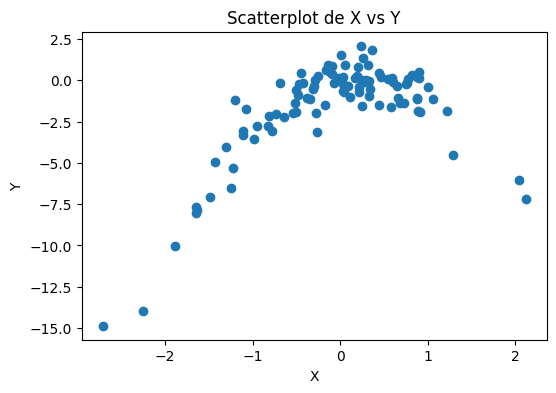

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot de X vs Y')
plt.show()

La gráfica nos muestra una relación no lineal entre X y Y, con una forma de una parábola.



> (c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:
1. Y = β0 + β1X + ε
2. Y = β0 + β1X + β2X2 + ε
3. Y = β0 + β1X + β2X2 + β3X3 + ε
4. Y = β0 + β1X + β2X2 + β3X3 + β4X4 + ε.


Note you may find it helpful to use the data.frame() function to create a single data set containing both X and Y .



In [100]:
df = pd.DataFrame({'x': x, 'y': y})

In [111]:
import numpy as np
from sklearn.linear_model import LinearRegression

def loocv_error(X, y):
    n = len(y)
    errors = []

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)

        X_test = X[i].reshape(1, -1)
        y_test = y[i]

        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)[0]

        errors.append((y_test - y_pred)**2)

    return np.mean(errors)

Modelo lineal

In [112]:
X1 = df[['x']].values
err1 = loocv_error(X1, df['y'].values)
err1

np.float64(6.633029839181983)

Modelo cuadrático

In [105]:
X2 = np.column_stack([df['x'], df['x']**2])
err2 = loocv_error(X2, df['y'].values)
err2

np.float64(1.1229368563419673)

Modleo cúbico

In [108]:
X3 = np.column_stack([df['x'], df['x']**2, df['x']**3])
err3 = loocv_error(X3, df['y'].values)
err3

np.float64(1.3017965489358851)

Modelo grado 4

In [107]:
X4 = np.column_stack([df['x'], df['x']**2, df['x']**3, df['x']**4])
err4 = loocv_error(X4, df['y'].values)
err4

np.float64(1.332394269417935)



>(d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?



In [113]:
rng = np.random.default_rng(2)

In [114]:
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

In [115]:
dfd = pd.DataFrame({'x': x, 'y': y})

In [116]:
def loocv_error(X, y):
    n = len(y)
    errors = []

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)

        X_test = X[i].reshape(1, -1)
        y_test = y[i]

        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)[0]

        errors.append((y_test - y_pred)**2)

    return np.mean(errors)

In [123]:
#modelo lineal
X1 = dfd[['x']].values
err1 = loocv_error(X1, dfd['y'].values)
err1

np.float64(7.560603694358579)

In [124]:
#modelo cuadrático
X2 = np.column_stack([dfd['x'], dfd['x']**2])
err2= loocv_error(X2, dfd['y'].values)
err2

np.float64(0.984037174458258)

In [125]:
#modelo cúbico
X3 = np.column_stack([dfd['x'], dfd['x']**2, dfd['x']**3])
err3 = loocv_error(X3, dfd['y'].values)
err3

np.float64(0.9682355765918605)

In [126]:
#modelo grado 4
X4 = np.column_stack([dfd['x'], dfd['x']**2, dfd['x']**3, dfd['x']**4])
err4 = loocv_error(X4, dfd['y'].values)
err4

np.float64(0.9659585554875685)



>(e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.


En el inciso c, el modelo con menor error LOOCV fue el modelo cuadrático con 1.122
Esto era de esperarse debido a que en la gráfica se muestra que la relación entre "y" y "x" es crudrática, por lo tanto, el modelo cuadrática es el adecuado.


Por elotro ado, en el inciso d los errores mas bajos fueron el cúbico y el de grado 4.



> (f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?



In [127]:
# modelo 1
X1 = sm.add_constant(df[['x']])
model1 = sm.OLS(df['y'], X1).fit()

# modelo 2
X2 = sm.add_constant(np.column_stack([df['x'], df['x']**2]))
model2 = sm.OLS(df['y'], X2).fit()

# modelo 3
X3 = sm.add_constant(np.column_stack([df['x'], df['x']**2, df['x']**3]))
model3 = sm.OLS(df['y'], X3).fit()

# modelo 4
X4 = sm.add_constant(np.column_stack([df['x'], df['x']**2, df['x']**3, df['x']**4]))
model4 = sm.OLS(df['y'], X4).fit()

In [128]:
print(model1.summary())
print(model2.summary())
print(model3.summary())
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     45.60
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.04e-09
Time:                        02:38:49   Log-Likelihood:                -230.83
No. Observations:                 100   AIC:                             465.7
Df Residuals:                      98   BIC:                             470.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4650      0.247     -5.937      0.0

Al analizar la significancia estadística de los coeficientes, se observa que en el modelo cuadrático los términos asociados a x y x^2 son altamente significativos. En los modelos de mayor grado, los términos adicionales como x^3
y x^4 no resultan significativos en general, lo que indica que no aportan mucha información relevante.

**9.** We will now consider the Boston housing data set, from the ISLP
library.

In [129]:
from ISLP import load_data

Boston = load_data("Boston")
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2




> (a) Based on this data set, provide an estimate for the population mean of medv. Call this estimate µˆ



In [130]:
media_mu = Boston['medv'].mean()
media_mu

np.float64(22.532806324110677)



> (b) Provide an estimate of the standard error of µˆ. Interpret this
result.
Hint: We can compute the standard error of the sample mean by
dividing the sample standard deviation by the square root of the
number of observations



In [131]:
s = Boston['medv'].std()
n = len(Boston)

se = s / np.sqrt(n)
se

np.float64(0.4088611474975351)



> (c) Now estimate the standard error of µˆ using the bootstrap. How
does this compare to your answer from (b)?



In [132]:
np.random.seed(1)

n = len(Boston)

boot_means = []

for i in range(1000):

    sample = Boston['medv'].sample(n, replace=True)

    boot_means.append(sample.mean())

boot_means = np.array(boot_means)

boot_se = boot_means.std()
boot_se

np.float64(0.412402701271868)



> (d) Based on your bootstrap estimate from (c), provide a 95 % confidence interval for the mean of medv. Compare it to the results
obtained by using



In [133]:
se_boot = boot_se

lower = media_mu - 2 * se_boot
upper = media_mu + 2 * se_boot

lower, upper

(np.float64(21.708000921566942), np.float64(23.35761172665441))



> (e) Based on this data set, provide an estimate, µˆmed, for the median
value of medv in the population.


In [134]:
median = Boston['medv'].median()
median

21.2



> (f) We now would like to estimate the standard error of µˆmed. Unfortunately, there is no simple formula for computing the standard
error of the median. Instead, estimate the standard error of the
median using the bootstrap. Comment on your findings.



In [135]:
np.random.seed(1)

n = len(Boston)

boot_medians = []

for i in range(1000):

    sample = Boston['medv'].sample(n, replace=True)

    boot_medians.append(sample.median())

boot_medians = np.array(boot_medians)

se_median = boot_medians.std()
se_median

np.float64(0.3745979044255317)



> (g) Based on this data set, provide an estimate for the tenth percentile of medv in Boston census tracts. Call this quantity µˆ0.1.
(You can use the np.percentile() function.)



In [136]:
percentil = np.percentile(Boston['medv'], 10)
percentil

np.float64(12.75)



> (h) Use the bootstrap to estimate the standard error of µˆ0.1. Comment on your findings.



In [137]:
np.random.seed(1)

n = len(Boston)

boot_p10 = []

for i in range(1000):

    sample = Boston['medv'].sample(n, replace=True)

    boot_p10.append(np.percentile(sample, 10))

boot_p10 = np.array(boot_p10)

se_p10 = boot_p10.std()
se_p10

np.float64(0.48836343024432116)